# RQ1 — Vulnerability Detection Conformity Results
Loads all per-seed metrics CSVs from `../results_todos/rq1/`, then visualizes accuracy, revision, and confidence metrics across models and conditions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results_todos/rq1")

RQ1_CONDITIONS = [
    "all_correct_absent", "all_correct_present",
    "mixed_absent",       "mixed_present",
    "all_wrong_absent",   "all_wrong_present",
    "ALL",
]
CONDITION_ORDER = [c for c in RQ1_CONDITIONS if c != "ALL"]
CONDITION_LABELS = {
    "all_correct_absent":  "All-correct\n(no auth)",
    "all_correct_present": "All-correct\n(auth)",
    "mixed_absent":        "Mixed\n(no auth)",
    "mixed_present":       "Mixed\n(auth)",
    "all_wrong_absent":    "All-wrong\n(no auth)",
    "all_wrong_present":   "All-wrong\n(auth)",
}

def dataset_of(csv_path):
    """Classify a metrics CSV as in-distribution (primevul) or out-of-distribution (ood_benchmark)."""
    name = csv_path.name
    if "ood_benchmark" in name:
        return "ood"
    if "primevul" in name:
        return "id"
    return None

id_dfs, ood_dfs = [], []
for csv_path in sorted(RESULTS_DIR.rglob("*.metrics.csv")):
    if "primevul_dataset" in csv_path.name or "_all_seeds" in csv_path.name:
        continue
    parts = csv_path.parts
    if not any(p.startswith("seed_") for p in parts):
        continue
    dataset = dataset_of(csv_path)
    if dataset is None:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["condition"].isin(RQ1_CONDITIONS)]
    if df.empty:
        continue
    (id_dfs if dataset == "id" else ood_dfs).append(df)

all_per_seed = pd.concat(id_dfs, ignore_index=True) if id_dfs else pd.DataFrame()
combined = all_per_seed.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

all_per_seed_ood = pd.concat(ood_dfs, ignore_index=True) if ood_dfs else pd.DataFrame()
combined_ood = all_per_seed_ood.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

MODELS = sorted(combined["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"In-distribution (primevul) conditions: {sorted(combined['condition'].unique())}")
print(f"Out-of-distribution (ood_benchmark) conditions: "
      f"{sorted(combined_ood['condition'].unique()) if not combined_ood.empty else 'no OOD data found'}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
In-distribution (primevul) conditions: ['ALL', 'all_correct_absent', 'all_correct_present', 'all_wrong_absent', 'all_wrong_present', 'mixed_absent', 'mixed_present']
Out-of-distribution (ood_benchmark) conditions: ['ALL', 'all_correct_absent', 'all_correct_present', 'all_wrong_absent', 'all_wrong_present', 'mixed_absent', 'mixed_present']


## Per-model metrics tables

In [2]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_model = combined[combined["model"] == model].copy()
    df_model = df_model[df_model["condition"].isin(CONDITION_ORDER)]
    present = [c for c in CONDITION_ORDER if c in df_model["condition"].values]
    df_model["condition"] = pd.Categorical(df_model["condition"], categories=present, ordered=True)
    df_model = df_model.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()}\n{'─'*60}")
    display(df_model.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
        .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
        .set_caption(model)
    )



────────────────────────────────────────────────────────────
  LLAMA31_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,53.2,57.0,3.8,34.2,28.6,40.6,-0.9
1,all_correct_present,500,53.2,57.0,3.8,34.2,28.6,40.6,-0.7
2,mixed_absent,500,53.2,48.4,-4.8,27.6,30.5,24.4,-0.8
3,mixed_present,500,53.2,49.2,-4.0,30.8,32.7,28.6,-0.6
4,all_wrong_absent,500,53.2,45.5,-7.7,28.5,34.0,22.2,-1.4
5,all_wrong_present,500,53.2,41.9,-11.3,32.1,40.9,22.2,-1.1



────────────────────────────────────────────────────────────
  MISTRAL_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,55.8,56.7,0.9,25.5,22.1,29.9,-0.8
1,all_correct_present,499,55.7,59.7,4.0,29.3,22.7,37.6,-0.9
2,mixed_absent,498,55.9,55.5,-0.4,2.8,2.9,2.7,0.0
3,mixed_present,498.33,55.8,54.0,-1.8,5.8,6.8,4.5,0.2
4,all_wrong_absent,497.33,55.9,43.5,-12.4,33.0,40.6,23.4,-0.5
5,all_wrong_present,499,55.9,40.9,-15.0,37.5,47.0,25.4,-0.6



────────────────────────────────────────────────────────────
  PHI35_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,50.4,67.2,16.8,16.8,0.0,33.9,0.0
1,all_correct_present,500,50.4,81.6,31.2,31.2,0.0,62.9,0.0
2,mixed_absent,500,50.4,51.4,1.0,1.8,0.8,2.8,0.0
3,mixed_present,500,50.4,51.6,1.2,8.0,6.8,9.3,0.0
4,all_wrong_absent,500,50.4,30.0,-20.4,20.4,40.5,0.0,0.0
5,all_wrong_present,500,50.4,15.4,-35.0,35.0,69.4,0.0,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,60.2,87.8,27.6,44.4,13.9,90.5,0.9
1,all_correct_present,500,60.2,91.0,30.8,44.0,11.0,94.0,0.9
2,mixed_absent,500,60.2,49.8,-10.4,38.4,40.5,35.2,0.9
3,mixed_present,500,60.2,50.8,-9.4,39.8,40.9,38.2,0.8
4,all_wrong_absent,500,60.2,9.8,-50.4,64.0,95.0,17.1,0.8
5,all_wrong_present,500,60.2,8.6,-51.6,63.6,95.7,15.1,0.9


## Round-1 vs Round-2 accuracy by condition

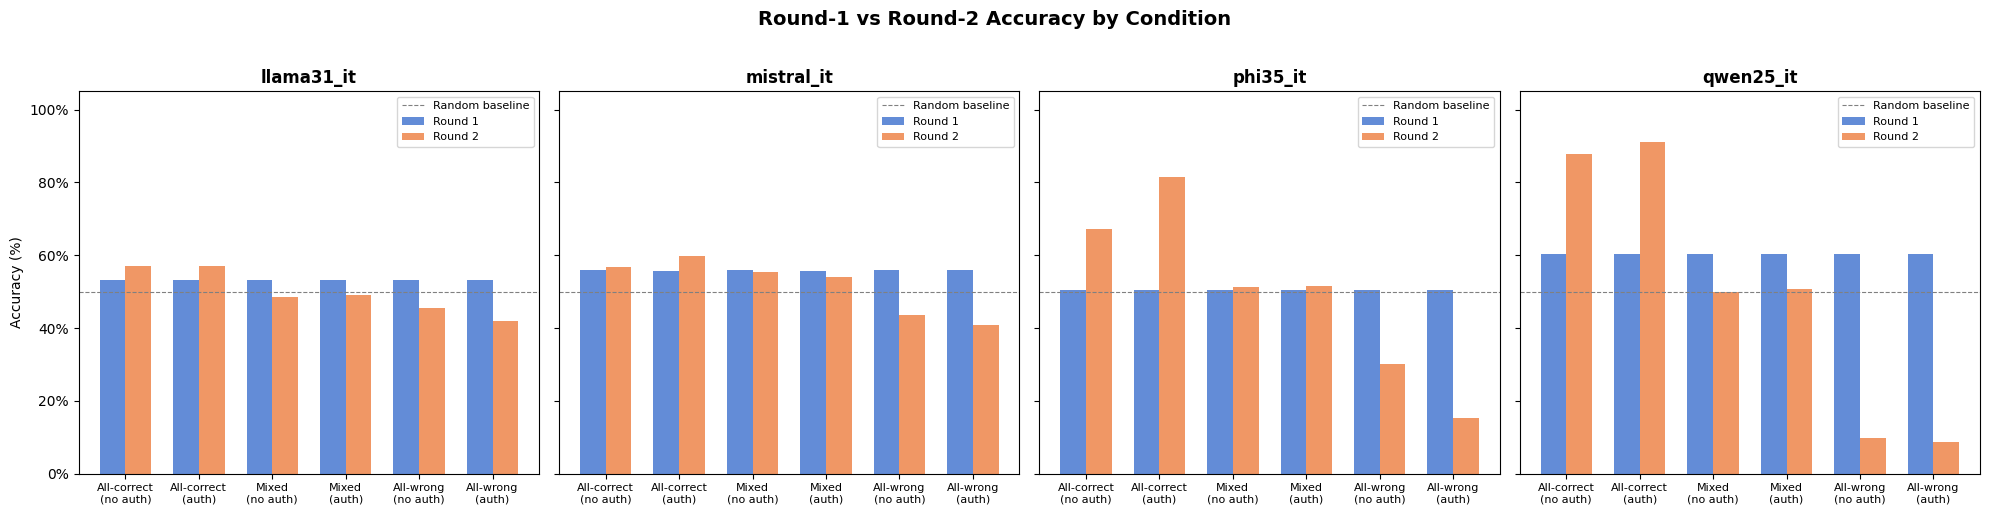

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(CONDITION_ORDER))].copy()
    present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")
    x = range(len(df_m))
    width = 0.35
    ax.bar([i - width/2 for i in x], df_m["acc_r1"], width, label="Round 1", color="#4878d0", alpha=0.85)
    ax.bar([i + width/2 for i in x], df_m["acc_r2"], width, label="Round 2", color="#ee854a", alpha=0.85)
    ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Random baseline")
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
    ax.set_ylabel("Accuracy (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)

plt.suptitle("Round-1 vs Round-2 Accuracy by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_r1_r2_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — models × conditions

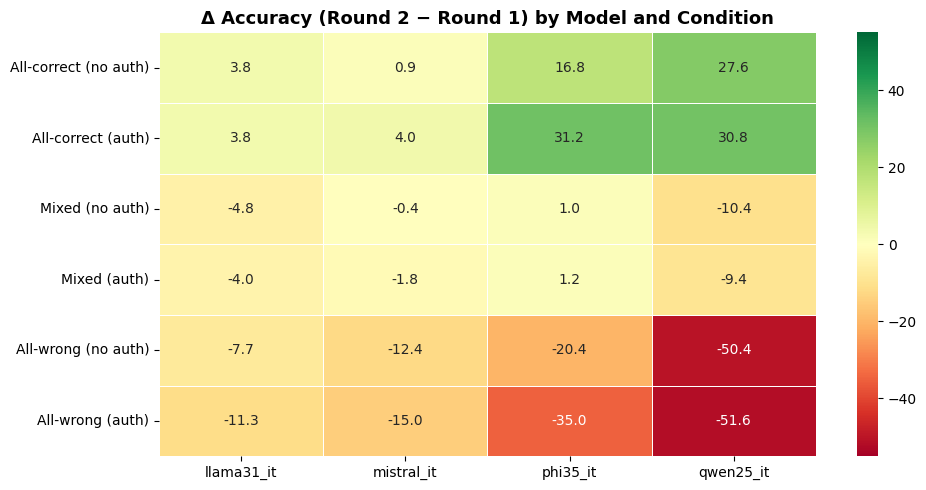

In [4]:
df_plot = combined[combined["condition"].isin(CONDITION_ORDER)]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([c for c in CONDITION_ORDER if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(MODELS)), 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("\u0394 Accuracy (Round 2 \u2212 Round 1) by Model and Condition", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "delta_acc_heatmap.png", dpi=150, bbox_inches="tight")
plt.savefig(RESULTS_DIR / "conformity_consensus_heatmap.pdf", bbox_inches="tight")
plt.show()


## Harmful vs Beneficial revision rate

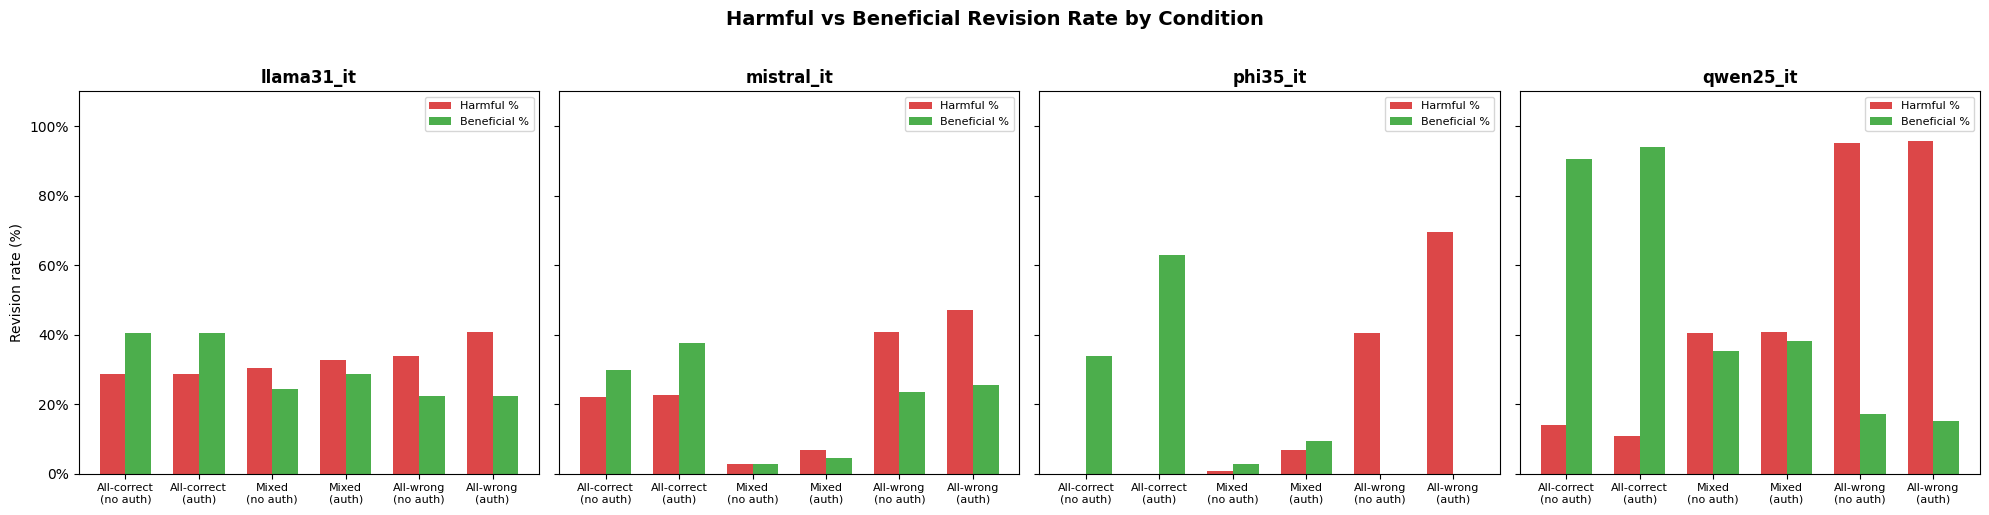

In [5]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(CONDITION_ORDER))].copy()
    present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")
    x = range(len(df_m))
    width = 0.35
    ax.bar([i - width/2 for i in x], df_m["harm_pct"], width, label="Harmful %", color="#d62728", alpha=0.85)
    ax.bar([i + width/2 for i in x], df_m["ben_pct"],  width, label="Beneficial %", color="#2ca02c", alpha=0.85)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
    ax.set_ylabel("Revision rate (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)

plt.suptitle("Harmful vs Beneficial Revision Rate by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "harmful_vs_beneficial.png", dpi=150, bbox_inches="tight")
plt.show()


## Cross-model accuracy drop under all-wrong consensus

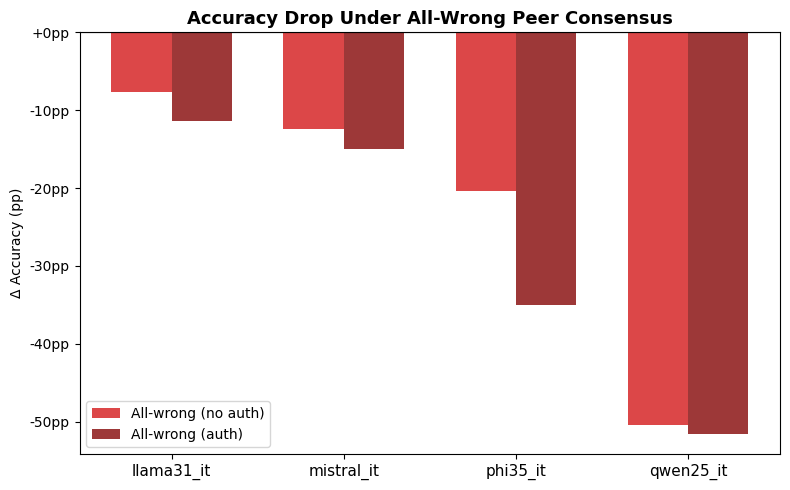

In [6]:
all_wrong = combined[combined["condition"].isin(["all_wrong_absent", "all_wrong_present"])].copy()

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(MODELS))
for i, cond in enumerate(["all_wrong_absent", "all_wrong_present"]):
    df_c = all_wrong[all_wrong["condition"] == cond].set_index("model")
    offsets = [j + i * 0.35 - 0.175 for j in x]
    vals = [df_c.loc[m, "delta_acc"] if m in df_c.index else 0 for m in MODELS]
    label = "All-wrong (no auth)" if "absent" in cond else "All-wrong (auth)"
    color = "#d62728" if "absent" in cond else "#8c1515"
    ax.bar(offsets, vals, 0.35, label=label, color=color, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel("\u0394 Accuracy (pp)")
ax.set_title("Accuracy Drop Under All-Wrong Peer Consensus", fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "allwrong_accuracy_drop.png", dpi=150, bbox_inches="tight")
plt.show()


## Mean confidence change heatmap

> **Note:** Phi-3.5-mini outputs a constant confidence of 7 regardless of condition — its `mean_dC` values are unreliable and are excluded from this heatmap.

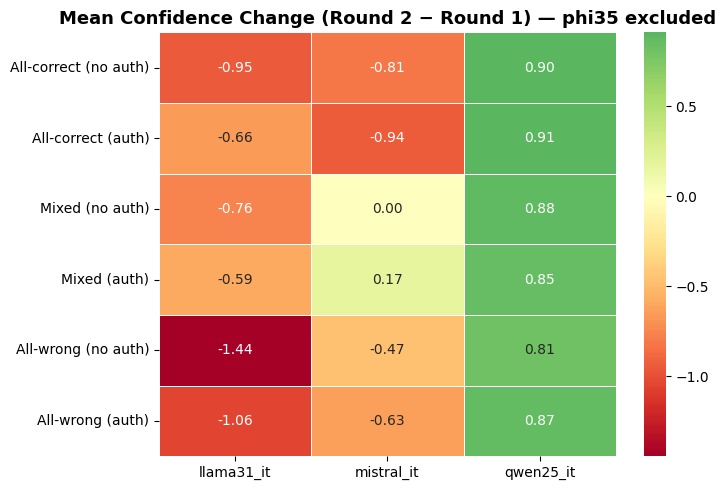

In [7]:
# FIX: exclude Phi35 from confidence heatmap — its confidence scores are unreliable (always 7)
CONFIDENCE_MODELS = [m for m in MODELS if m != "phi35_it"]

df_plot = combined[(combined["condition"].isin(CONDITION_ORDER)) & (combined["model"].isin(CONFIDENCE_MODELS))]
pivot_dc = df_plot.pivot_table(index="condition", columns="model", values="mean_dC")
pivot_dc = pivot_dc.reindex([c for c in CONDITION_ORDER if c in pivot_dc.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(CONFIDENCE_MODELS)), 5))
sns.heatmap(pivot_dc, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Mean Confidence Change (Round 2 \u2212 Round 1) — phi35 excluded", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot_dc.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confidence_change_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# Out-of-Distribution (OOD) Results

Everything below repeats the analysis above using the `ood_benchmark_rq1_rq3` files instead of `primevul_rq1_rq3` — i.e. functions drawn from a different vulnerability benchmark than the one used for in-distribution (ID) evaluation. Comparing the two tells us whether the peer-conformity effect is a property of the model's behavior in general, or an artifact tied to the specific ID dataset.

## Per-model metrics tables — OOD

In [8]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                    "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

    for model in MODELS:
        df_model = combined_ood[combined_ood["model"] == model].copy()
        df_model = df_model[df_model["condition"].isin(CONDITION_ORDER)]
        present = [c for c in CONDITION_ORDER if c in df_model["condition"].values]
        df_model["condition"] = pd.Categorical(df_model["condition"], categories=present, ordered=True)
        df_model = df_model.sort_values("condition")[display_cols].reset_index(drop=True)
        print(f"\n{'─'*60}\n  {model.upper()} — OOD\n{'─'*60}")
        display(df_model.style
            .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                     **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
            .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
            .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
            .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
            .set_caption(f"{model} — OOD")
        )



────────────────────────────────────────────────────────────
  LLAMA31_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,52.9,55.6,2.7,35.7,31.2,40.8,-0.7
1,all_correct_present,500,52.9,58.7,5.8,38.9,31.2,47.4,-0.6
2,mixed_absent,500,52.9,48.3,-4.6,32.1,34.6,29.2,-0.5
3,mixed_present,500,52.9,48.7,-4.3,34.0,36.1,31.6,-0.5
4,all_wrong_absent,500,52.9,44.9,-8.0,31.6,37.4,25.1,-1.3
5,all_wrong_present,500,52.9,43.7,-9.3,32.9,39.8,25.1,-1.3



────────────────────────────────────────────────────────────
  MISTRAL_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,499.67,53.8,58.0,4.2,20.6,15.3,26.8,-0.7
1,all_correct_present,498.33,53.6,58.9,5.3,25.2,18.6,32.9,-0.7
2,mixed_absent,499.33,53.7,53.9,0.2,1.0,0.7,1.3,-0.1
3,mixed_present,497,53.8,54.2,0.4,5.2,4.5,6.1,0.1
4,all_wrong_absent,497.33,53.9,42.6,-11.3,26.1,34.7,16.1,-0.5
5,all_wrong_present,499,53.8,45.2,-8.6,27.1,33.1,20.0,-0.5



────────────────────────────────────────────────────────────
  PHI35_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,50.2,65.4,15.2,15.2,0.0,30.5,0.0
1,all_correct_present,500,50.2,81.2,31.0,31.0,0.0,62.2,0.0
2,mixed_absent,500,50.2,49.7,-0.5,1.9,2.4,1.3,0.0
3,mixed_present,500,50.2,51.8,1.6,6.8,5.2,8.4,0.0
4,all_wrong_absent,500,50.2,32.4,-17.8,17.8,35.5,0.0,0.0
5,all_wrong_present,500,50.2,20.6,-29.6,29.6,59.0,0.0,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,56.6,93.3,36.7,48.1,10.0,97.7,0.8
1,all_correct_present,500,56.6,97.9,41.3,45.5,3.8,100.0,0.9
2,mixed_absent,500,56.6,51.2,-5.4,38.6,38.9,38.2,0.8
3,mixed_present,500,56.6,47.7,-8.9,37.8,41.2,33.3,0.8
4,all_wrong_absent,500,56.6,6.6,-50.0,58.4,95.8,9.7,0.7
5,all_wrong_present,500,56.6,4.1,-52.5,57.3,97.1,5.5,0.9


## Round-1 vs Round-2 accuracy by condition — OOD

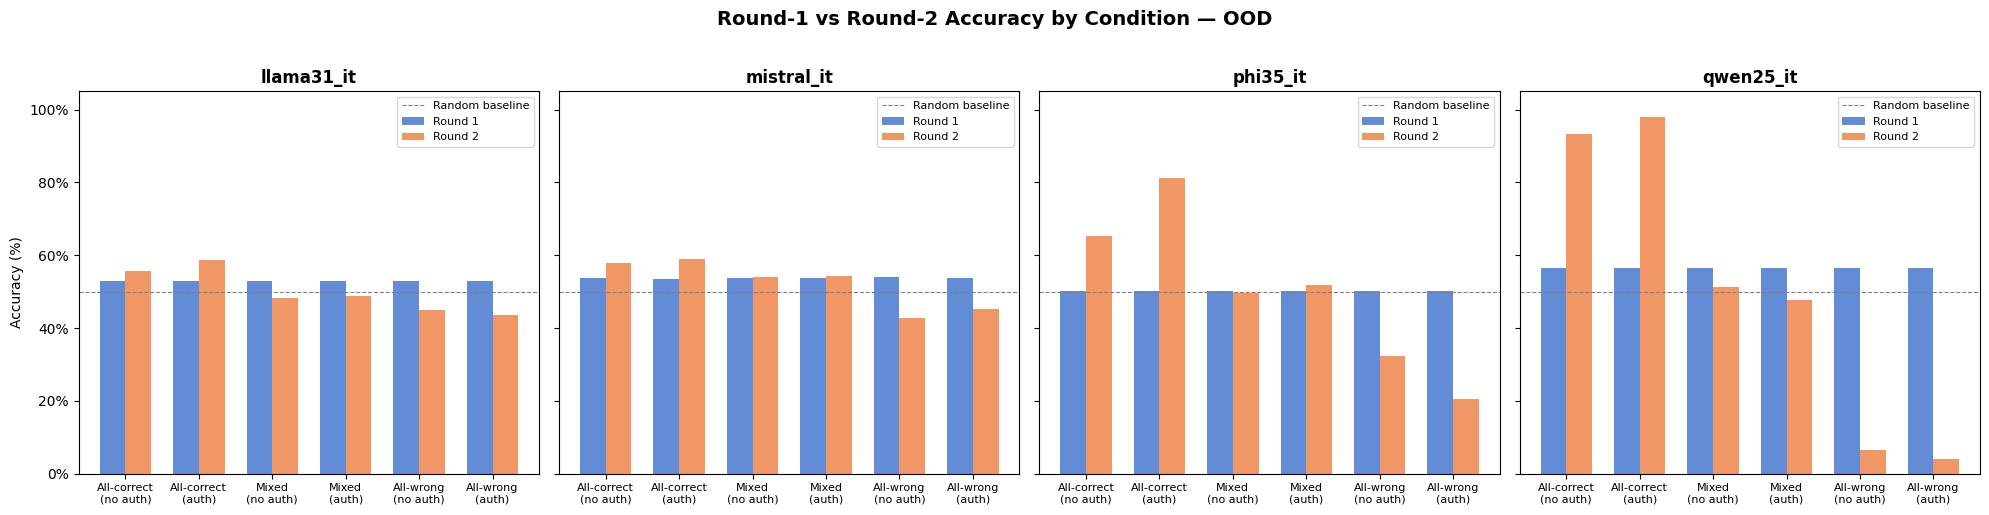

In [9]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin(CONDITION_ORDER))].copy()
        present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")
        x = range(len(df_m))
        width = 0.35
        ax.bar([i - width/2 for i in x], df_m["acc_r1"], width, label="Round 1", color="#4878d0", alpha=0.85)
        ax.bar([i + width/2 for i in x], df_m["acc_r2"], width, label="Round 2", color="#ee854a", alpha=0.85)
        ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Random baseline")
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks(list(x))
        ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
        ax.set_ylabel("Accuracy (%)" if ax == axes[0] else "")
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=8)

    plt.suptitle("Round-1 vs Round-2 Accuracy by Condition — OOD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ood_accuracy_r1_r2_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()


## Δ Accuracy heatmap — models × conditions — OOD

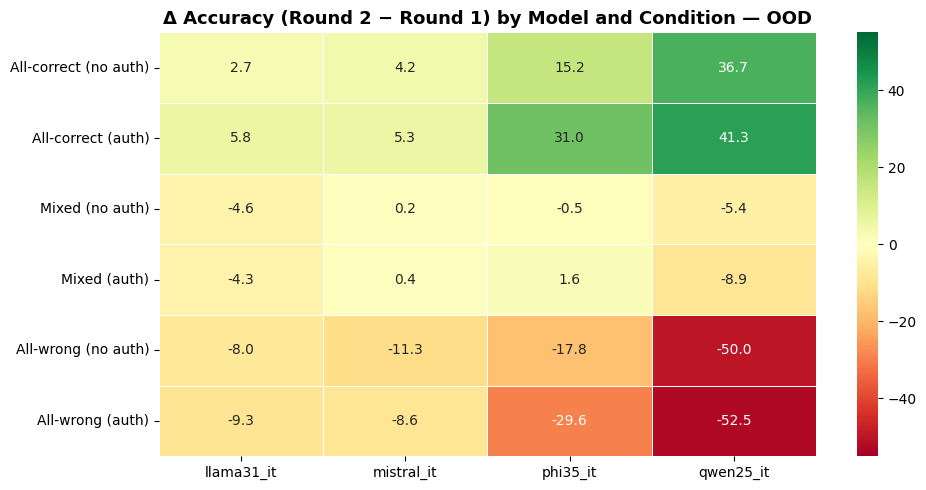

In [10]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    df_plot = combined_ood[combined_ood["condition"].isin(CONDITION_ORDER)]
    pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
    pivot = pivot.reindex([c for c in CONDITION_ORDER if c in pivot.index])

    fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(MODELS)), 5))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
                linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("Δ Accuracy (Round 2 − Round 1) by Model and Condition — OOD", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ood_delta_acc_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


## Harmful vs Beneficial revision rate — OOD

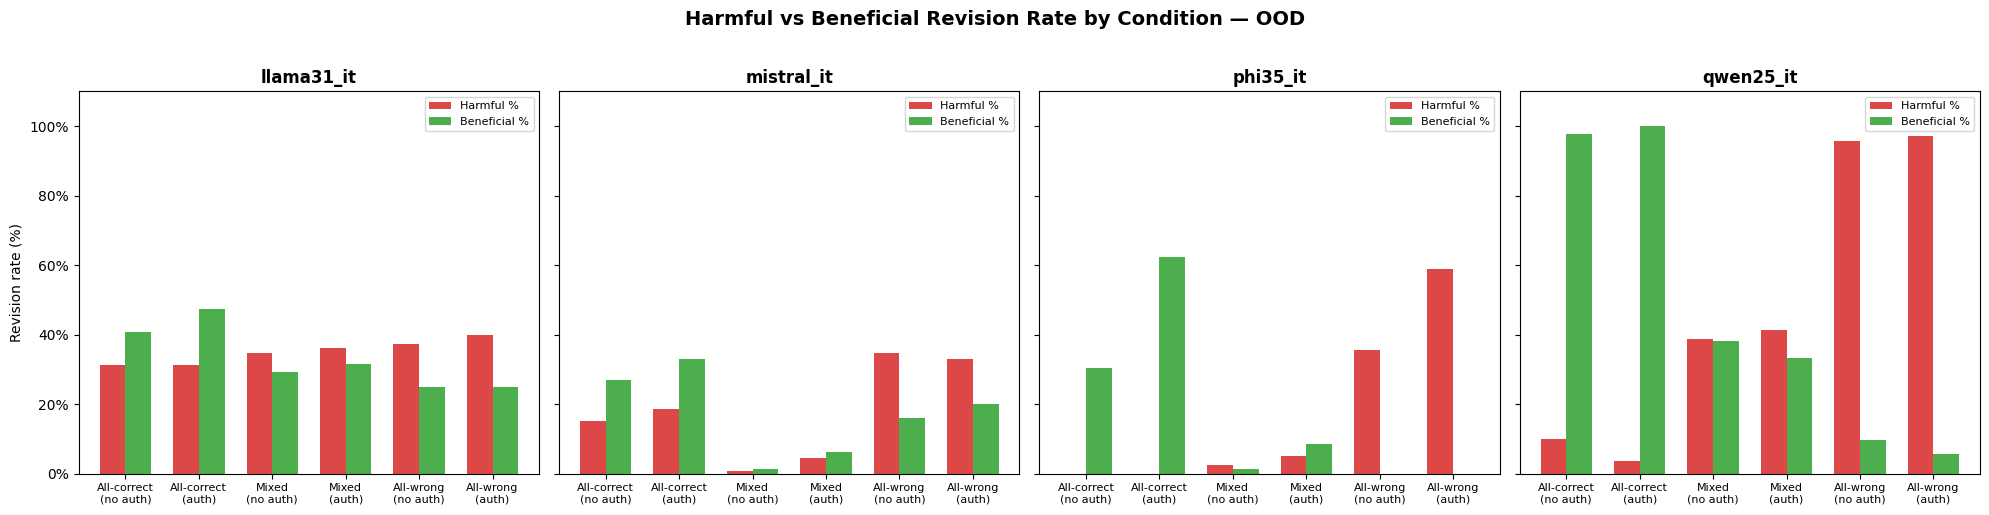

In [11]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin(CONDITION_ORDER))].copy()
        present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")
        x = range(len(df_m))
        width = 0.35
        ax.bar([i - width/2 for i in x], df_m["harm_pct"], width, label="Harmful %", color="#d62728", alpha=0.85)
        ax.bar([i + width/2 for i in x], df_m["ben_pct"],  width, label="Beneficial %", color="#2ca02c", alpha=0.85)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks(list(x))
        ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
        ax.set_ylabel("Revision rate (%)" if ax == axes[0] else "")
        ax.set_ylim(0, 110)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=8)

    plt.suptitle("Harmful vs Beneficial Revision Rate by Condition — OOD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ood_harmful_vs_beneficial.png", dpi=150, bbox_inches="tight")
    plt.show()


## Cross-model accuracy drop under all-wrong consensus — OOD

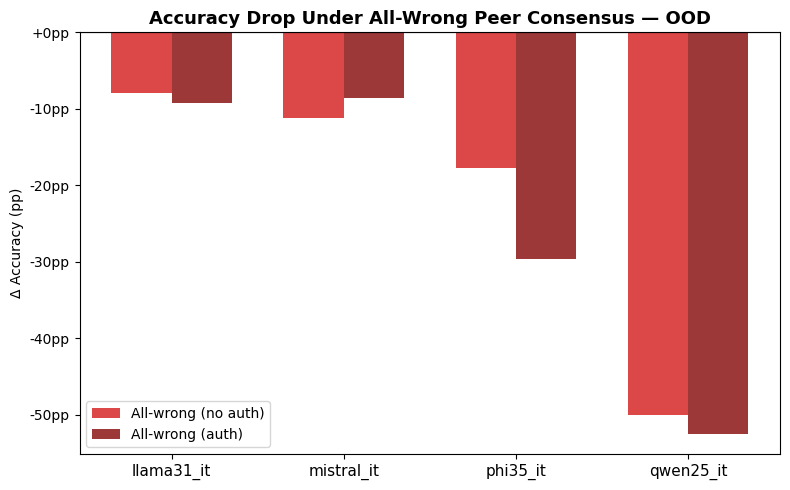

In [12]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    all_wrong_ood = combined_ood[combined_ood["condition"].isin(["all_wrong_absent", "all_wrong_present"])].copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    x = range(len(MODELS))
    for i, cond in enumerate(["all_wrong_absent", "all_wrong_present"]):
        df_c = all_wrong_ood[all_wrong_ood["condition"] == cond].set_index("model")
        offsets = [j + i * 0.35 - 0.175 for j in x]
        vals = [df_c.loc[m, "delta_acc"] if m in df_c.index else 0 for m in MODELS]
        label = "All-wrong (no auth)" if "absent" in cond else "All-wrong (auth)"
        color = "#d62728" if "absent" in cond else "#8c1515"
        ax.bar(offsets, vals, 0.35, label=label, color=color, alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(MODELS, fontsize=11)
    ax.set_ylabel("Δ Accuracy (pp)")
    ax.set_title("Accuracy Drop Under All-Wrong Peer Consensus — OOD", fontsize=13, fontweight="bold")
    ax.legend()
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ood_allwrong_accuracy_drop.png", dpi=150, bbox_inches="tight")
    plt.show()


## Mean confidence change heatmap — OOD

> **Note:** Phi-3.5-mini outputs a constant confidence of 7 regardless of condition — its `mean_dC` values are unreliable and are excluded from this heatmap.

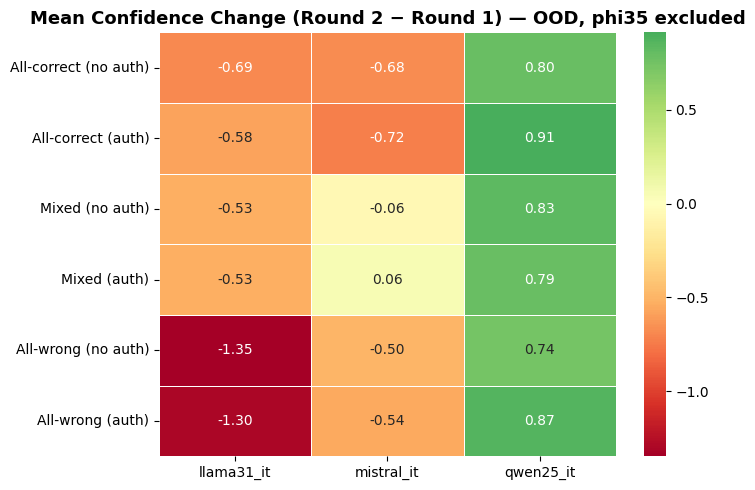

In [13]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    # FIX: exclude Phi35 from confidence heatmap — its confidence scores are unreliable (always 7)
    CONFIDENCE_MODELS = [m for m in MODELS if m != "phi35_it"]

    df_plot = combined_ood[(combined_ood["condition"].isin(CONDITION_ORDER)) & (combined_ood["model"].isin(CONFIDENCE_MODELS))]
    pivot_dc = df_plot.pivot_table(index="condition", columns="model", values="mean_dC")
    pivot_dc = pivot_dc.reindex([c for c in CONDITION_ORDER if c in pivot_dc.index])

    fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(CONFIDENCE_MODELS)), 5))
    sns.heatmap(pivot_dc, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("Mean Confidence Change (Round 2 − Round 1) — OOD, phi35 excluded", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot_dc.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ood_confidence_change_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


## ID vs OOD: Δ Accuracy comparison

Directly compares the conformity effect (Δ Accuracy, Round 2 − Round 1) on in-distribution (primevul) vs out-of-distribution (ood_benchmark) instances, per model and condition.

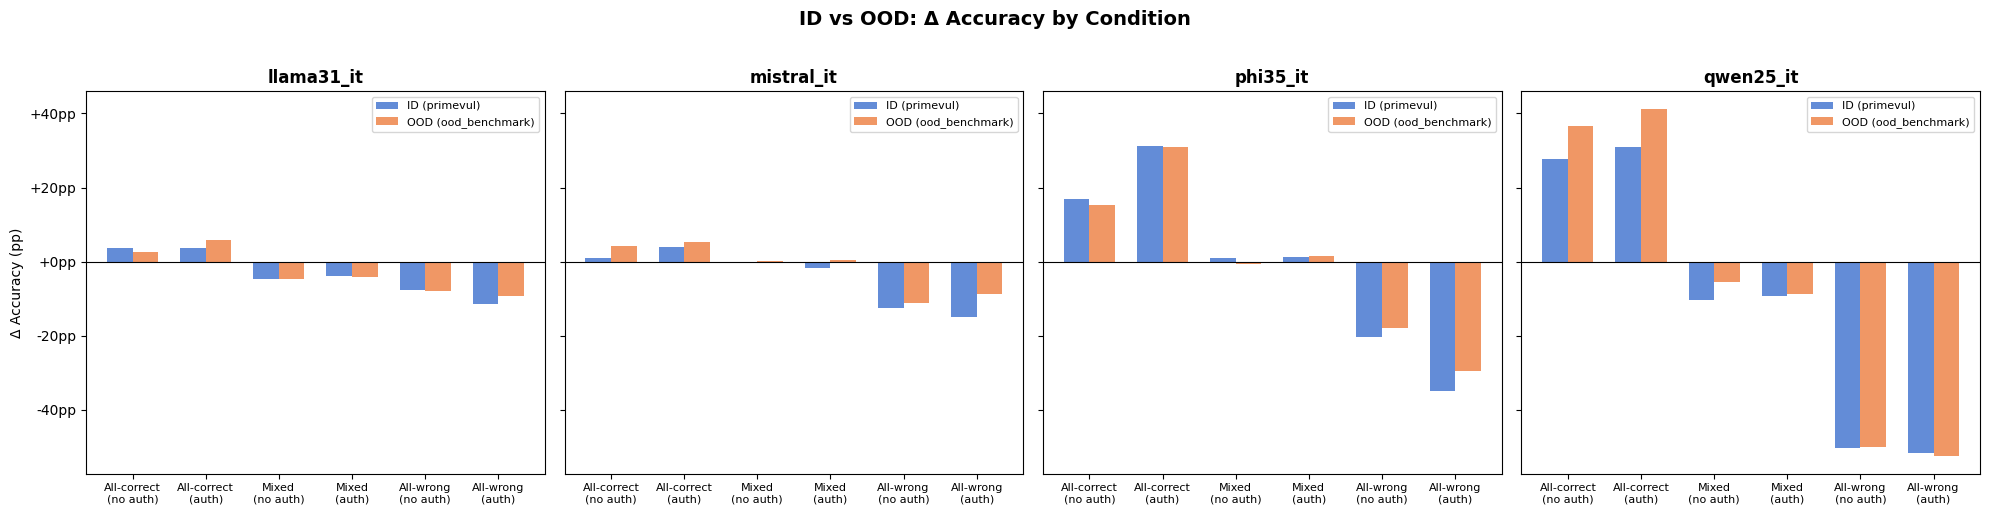

In [14]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        for df, label, color in [(combined, "ID (primevul)", "#4878d0"), (combined_ood, "OOD (ood_benchmark)", "#ee854a")]:
            df_m = df[(df["model"] == model) & (df["condition"].isin(CONDITION_ORDER))].copy()
            present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
            df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
            df_m = df_m.sort_values("condition")
            x = range(len(df_m))
            offset = -0.175 if label.startswith("ID") else 0.175
            ax.bar([i + offset for i in x], df_m["delta_acc"], 0.35, label=label, color=color, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks(list(range(len(CONDITION_ORDER))))
        ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in CONDITION_ORDER], fontsize=8)
        ax.set_ylabel("Δ Accuracy (pp)" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

    plt.suptitle("ID vs OOD: Δ Accuracy by Condition", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "id_vs_ood_delta_acc.png", dpi=150, bbox_inches="tight")
    plt.show()
